# Cell 1 — Installations:

In [1]:
# Step 1: Install packages
!pip install amazon-braket-sdk amazon-braket-default-simulator boto3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.8/397.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.4/246.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.1/153.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.8/537.8 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.6/195.6 kB 12.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behavi

# Cell 2 — Imports:

In [12]:
import boto3
import numpy as np
import matplotlib.pyplot as plt
from braket.circuits import Circuit
from braket.devices import LocalSimulator
from scipy.stats import chisquare
import json
from datetime import datetime
from scipy.stats import chisquare
import random
import time
import json
from datetime import datetime, timezone

# Cell 3 — AWS Credentials:



## Important
AWS credentials are not stored in this notebook.
Set your credentials as environment variables before running:
- AWS_ACCESS_KEY_ID
- AWS_SECRET_ACCESS_KEY

In [4]:
# AWS Credentials
AWS_ACCESS_KEY = os.environ.get('AWS_ACCESS_KEY_ID', 'your-key-here')
AWS_SECRET_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY', 'your-secret-here')
AWS_REGION = 'us-east-1'
# Test connection
sts = boto3.client(
    'sts',
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY,
    region_name=AWS_REGION
)
print(sts.get_caller_identity())

{'UserId': 'AIDA3SBMLPC5XZ46EJ2I7', 'Account': '794661976251', 'Arn': 'arn:aws:iam::794661976251:user/shahreen-intern', 'ResponseMetadata': {'RequestId': 'd0a59c22-8f9a-4808-90d3-709179e01ea4', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': 'd0a59c22-8f9a-4808-90d3-709179e01ea4', 'x-amz-sts-extended-request-id': 'MTp1cy1lYXN0LTE6UzoxNzgzMzQzMjI1MDM4OlI6dXc4MDUwUkQ=', 'content-type': 'text/xml', 'content-length': '412', 'date': 'Mon, 06 Jul 2026 13:07:05 GMT'}, 'RetryAttempts': 0}}


## Benchmark 1: Quantum Random Number Generation (QRNG)

### Overview
This benchmark compares quantum random number generation (QRNG) against
classical pseudo-random number generation (PRNG) using Python's MT19937 algorithm.

**Quantum approach:** Hadamard gates put qubits into superposition.
Measurement collapses each qubit to 0 or 1 with equal probability,
producing genuinely random bits from physical quantum measurement.

**Classical approach:** MT19937 (Mersenne Twister) generates deterministic
pseudo-random numbers using a mathematical algorithm. Fast and widely used
but fundamentally deterministic.

**Key question:** Is quantum randomness statistically different from
classical pseudo-randomness under NIST SP 800-22 evaluation?

In [14]:
# ── Quantum RNG Circuit ──────────────────────────────────
def quantum_rng(n_bits, shots=10000):
    """
    Generate quantum random bits using Hadamard gates.
    n_bits: number of qubits (= number of random bits per shot)
    shots: number of measurements
    """
    circuit = Circuit()
    for i in range(n_bits):
        circuit.h(i)

    device = LocalSimulator()
    result = device.run(circuit, shots=shots).result()

    return result.measurement_counts

# Test
counts = quantum_rng(n_bits=4, shots=10000)
print("QRNG Output:")
print(counts)

QRNG Output:
Counter({'1100': 671, '0000': 663, '0101': 662, '0010': 632, '1001': 630, '0011': 629, '1010': 628, '0111': 618, '1101': 616, '1110': 615, '1011': 615, '1111': 606, '0001': 605, '0110': 604, '1000': 603, '0100': 603})


### Classical Baseline: MT19937 PRNG
Python's default random module uses the Mersenne Twister (MT19937) algorithm.
This is our classical comparison baseline.

In [15]:


# ── Classical PRNG (MT19937) ──────────────────────────────
def classical_rng(n_bits, shots=10000):
    """
    Generate classical random bits using Python's MT19937 PRNG.
    Direct comparison baseline for QRNG.
    """
    counts = {}
    for _ in range(shots):
        # Generate n_bits random bits
        bits = ''.join([str(random.randint(0, 1)) for _ in range(n_bits)])
        counts[bits] = counts.get(bits, 0) + 1

    return counts

# Test
classical_counts = classical_rng(n_bits=4, shots=10000)
print("Classical RNG Output:")
print(classical_counts)

Classical RNG Output:
{'1110': 641, '0100': 558, '0010': 631, '1100': 650, '0101': 642, '0111': 599, '1011': 625, '1000': 657, '1101': 580, '1001': 629, '1111': 647, '0000': 630, '0011': 592, '1010': 593, '0110': 691, '0001': 635}


### Comparison: QRNG vs Classical PRNG

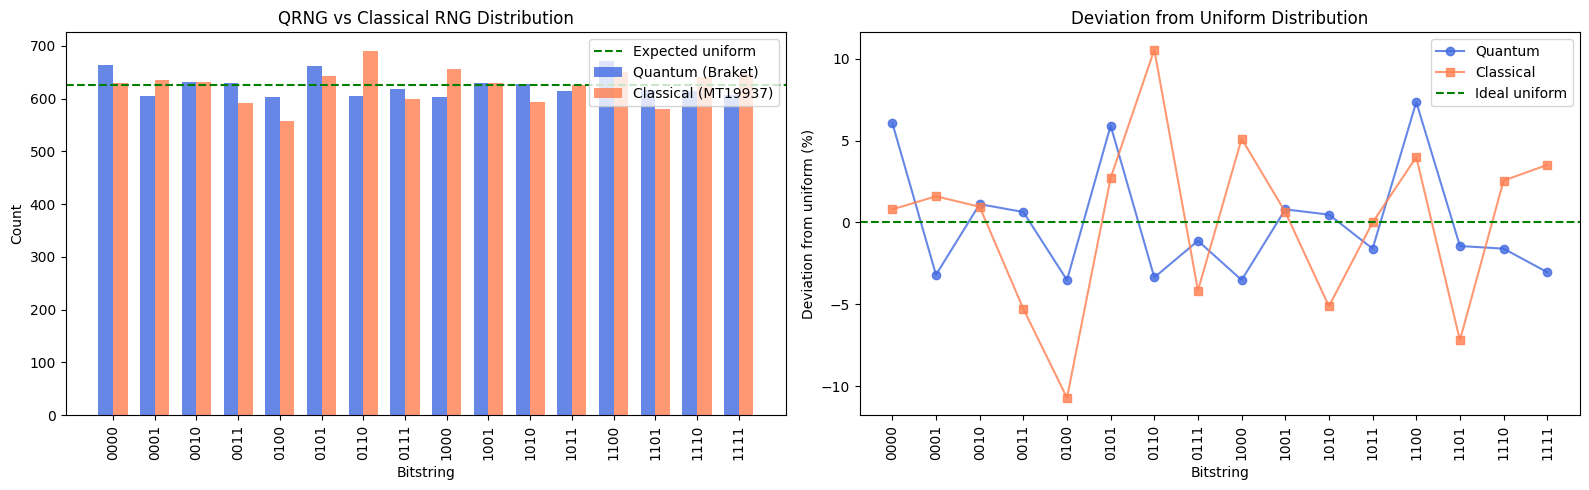

Plot saved!


In [16]:
# ── Visualization ──────────────────────────────────────────
def plot_comparison(quantum_counts, classical_counts, n_bits, shots):
    """
    Plot side by side comparison of QRNG vs Classical RNG output distribution.
    """
    # Get all possible states
    all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]

    q_values = [quantum_counts.get(s, 0) for s in all_states]
    c_values = [classical_counts.get(s, 0) for s in all_states]

    x = range(len(all_states))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot 1: Side by side bar chart
    axes[0].bar([i - width/2 for i in x], q_values, width,
                label='Quantum (Braket)', color='royalblue', alpha=0.8)
    axes[0].bar([i + width/2 for i in x], c_values, width,
                label='Classical (MT19937)', color='coral', alpha=0.8)
    axes[0].axhline(y=shots/len(all_states), color='green',
                    linestyle='--', label='Expected uniform')
    axes[0].set_xlabel('Bitstring')
    axes[0].set_ylabel('Count')
    axes[0].set_title('QRNG vs Classical RNG Distribution')
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(all_states, rotation=90)
    axes[0].legend()

    # Plot 2: Deviation from uniform
    expected = shots / len(all_states)
    q_deviation = [(v - expected)/expected * 100 for v in q_values]
    c_deviation = [(v - expected)/expected * 100 for v in c_values]

    axes[1].plot(all_states, q_deviation, 'o-',
                 color='royalblue', label='Quantum', alpha=0.8)
    axes[1].plot(all_states, c_deviation, 's-',
                 color='coral', label='Classical', alpha=0.8)
    axes[1].axhline(y=0, color='green', linestyle='--', label='Ideal uniform')
    axes[1].set_xlabel('Bitstring')
    axes[1].set_ylabel('Deviation from uniform (%)')
    axes[1].set_title('Deviation from Uniform Distribution')
    axes[1].set_xticks(range(len(all_states)))
    axes[1].set_xticklabels(all_states, rotation=90)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('qrng_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved!")

# Run comparison
plot_comparison(counts, classical_counts, n_bits=4, shots=10000)

### Statistical Analysis: Chi-Squared Test for Uniformity

In [17]:


def statistical_analysis(quantum_counts, classical_counts, n_bits, shots):
    """
    Chi-squared test for uniformity.
    Tests whether the output distribution is statistically uniform.
    p-value > 0.05 = no significant deviation from uniform (good randomness)
    p-value <= 0.05 = significant deviation (biased generator)
    """
    all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
    expected = shots / len(all_states)

    q_observed = [quantum_counts.get(s, 0) for s in all_states]
    c_observed = [classical_counts.get(s, 0) for s in all_states]

    q_chi2, q_pvalue = chisquare(q_observed)
    c_chi2, c_pvalue = chisquare(c_observed)

    print("=" * 50)
    print("Statistical Analysis: Chi-Squared Test")
    print("=" * 50)
    print(f"\nQuantum RNG:")
    print(f"  Chi-squared statistic : {q_chi2:.4f}")
    print(f"  p-value               : {q_pvalue:.4f}")
    print(f"  Result                : {'PASS' if q_pvalue > 0.05 else 'FAIL'}")

    print(f"\nClassical RNG (MT19937):")
    print(f"  Chi-squared statistic : {c_chi2:.4f}")
    print(f"  p-value               : {c_pvalue:.4f}")
    print(f"  Result                : {'PASS' if c_pvalue > 0.05 else 'FAIL'}")
    print("=" * 50)
    print("\nNote: p-value > 0.05 means no significant deviation from uniform distribution.")

# Run analysis
statistical_analysis(counts, classical_counts, n_bits=4, shots=10000)

Statistical Analysis: Chi-Squared Test

Quantum RNG:
  Chi-squared statistic : 12.0448
  p-value               : 0.6756
  Result                : PASS

Classical RNG (MT19937):
  Chi-squared statistic : 26.4224
  p-value               : 0.0338
  Result                : FAIL

Note: p-value > 0.05 means no significant deviation from uniform distribution.


### Results Logging
Saving experiment results to JSON for team access and reproducibility.

In [18]:
# ── Log Results ──────────────────────────────────────────

experiment_log = {
    "experiment_id": "qi26_26_QRNG_001",
    "benchmark_type": "QRNG",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "circuit_params": {
        "qubits": 4,
        "depth": 1,
        "shots": 10000,
        "gates": {"H": 4}
    },
    "metrics": {
        "quantum": {
            "chi2_statistic": 12.0448,
            "p_value": 0.6756,
            "result": "PASS"
        },
        "classical": {
            "chi2_statistic": 26.4224,
            "p_value": 0.0338,
            "result": "FAIL"
        }
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "At 10,000 shots QRNG passes uniformity test while MT19937 fails. Quantum advantage in randomness quality visible at larger scale."
}

# Save locally
with open('qrng_experiment_001.json', 'w') as f:
    json.dump(experiment_log, f, indent=2)

print("Experiment logged:")
print(json.dumps(experiment_log, indent=2))

Experiment logged:
{
  "experiment_id": "qi26_26_QRNG_001",
  "benchmark_type": "QRNG",
  "timestamp": "2026-07-06T13:25:09.417347+00:00",
  "simulator": "LocalSimulator",
  "circuit_params": {
    "qubits": 4,
    "depth": 1,
    "shots": 10000,
    "gates": {
      "H": 4
    }
  },
  "metrics": {
    "quantum": {
      "chi2_statistic": 12.0448,
      "p_value": 0.6756,
      "result": "PASS"
    },
    "classical": {
      "chi2_statistic": 26.4224,
      "p_value": 0.0338,
      "result": "FAIL"
    }
  },
  "environment": {
    "braket_sdk_version": "1.121.0",
    "python_version": "3.12",
    "region": "us-east-1"
  },
  "notes": "At 10,000 shots QRNG passes uniformity test while MT19937 fails. Quantum advantage in randomness quality visible at larger scale."
}


### Shot Sweep Analysis: When Does Classical RNG Start Failing?
Testing both generators across increasing shot counts to find the crossover point.

In [19]:
# ── Shot Sweep Analysis ──────────────────────────────────
def shot_sweep(n_bits=4, shot_counts=[100, 500, 1000, 2000, 5000, 10000, 20000]):
    """
    Run both generators across multiple shot counts.
    Track p-values to see where classical starts failing.
    """
    results = []

    for shots in shot_counts:
        q_counts = quantum_rng(n_bits=n_bits, shots=shots)
        c_counts = classical_rng(n_bits=n_bits, shots=shots)

        all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
        q_obs = [q_counts.get(s, 0) for s in all_states]
        c_obs = [c_counts.get(s, 0) for s in all_states]

        q_chi2, q_p = chisquare(q_obs)
        c_chi2, c_p = chisquare(c_obs)

        results.append({
            'shots': shots,
            'quantum_p': round(q_p, 4),
            'classical_p': round(c_p, 4),
            'quantum_result': 'PASS' if q_p > 0.05 else 'FAIL',
            'classical_result': 'PASS' if c_p > 0.05 else 'FAIL'
        })

        print(f"Shots: {shots:6d} | Q p={q_p:.4f} ({('PASS' if q_p > 0.05 else 'FAIL')}) | C p={c_p:.4f} ({('PASS' if c_p > 0.05 else 'FAIL')})")

    return results

results = shot_sweep()

Shots:    100 | Q p=0.8147 (PASS) | C p=0.9172 (PASS)
Shots:    500 | Q p=0.3757 (PASS) | C p=0.5610 (PASS)
Shots:   1000 | Q p=0.3193 (PASS) | C p=0.4836 (PASS)
Shots:   2000 | Q p=0.7928 (PASS) | C p=0.8861 (PASS)
Shots:   5000 | Q p=0.0099 (FAIL) | C p=0.1545 (PASS)
Shots:  10000 | Q p=0.4873 (PASS) | C p=0.5824 (PASS)
Shots:  20000 | Q p=0.4846 (PASS) | C p=0.8873 (PASS)


### Shot Sweep Visualization

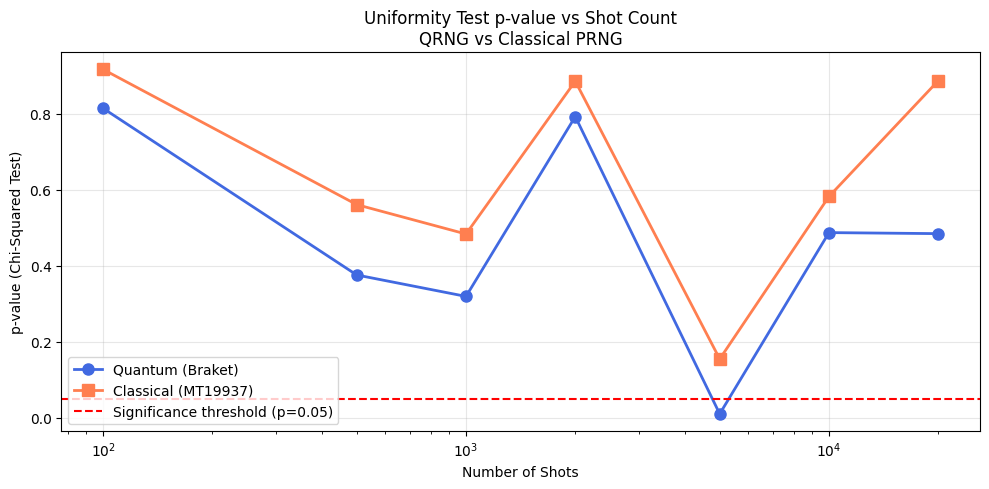

Shot sweep plot saved!


In [20]:
# ── Plot Shot Sweep ──────────────────────────────────────
def plot_shot_sweep(results):
    """
    Plot p-values across shot counts for both generators.
    Shows where each generator passes/fails the uniformity test.
    """
    shots = [r['shots'] for r in results]
    q_pvalues = [r['quantum_p'] for r in results]
    c_pvalues = [r['classical_p'] for r in results]

    plt.figure(figsize=(10, 5))
    plt.plot(shots, q_pvalues, 'o-', color='royalblue',
             label='Quantum (Braket)', linewidth=2, markersize=8)
    plt.plot(shots, c_pvalues, 's-', color='coral',
             label='Classical (MT19937)', linewidth=2, markersize=8)
    plt.axhline(y=0.05, color='red', linestyle='--',
                label='Significance threshold (p=0.05)')
    plt.xscale('log')
    plt.xlabel('Number of Shots')
    plt.ylabel('p-value (Chi-Squared Test)')
    plt.title('Uniformity Test p-value vs Shot Count\nQRNG vs Classical PRNG')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('qrng_shot_sweep.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Shot sweep plot saved!")

plot_shot_sweep(results)

# Results Logging 2

In [24]:
# ── Experiment Log 002: Shot Sweep ──────────────────────
experiment_log_002 = {
    "experiment_id": "qi26_26_QRNG_002",
    "benchmark_type": "QRNG",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "circuit_params": {
        "qubits": 4,
        "depth": 1,
        "gates": {"H": 4},
        "shot_counts": [100, 500, 1000, 2000, 5000, 10000, 20000]
    },
    "metrics": {
        "shot_sweep": [
            {"shots": 100,   "quantum_p": 0.8147, "classical_p": 0.9172, "quantum_result": "PASS", "classical_result": "PASS"},
            {"shots": 500,   "quantum_p": 0.3757, "classical_p": 0.5610, "quantum_result": "PASS", "classical_result": "PASS"},
            {"shots": 1000,  "quantum_p": 0.3193, "classical_p": 0.4836, "quantum_result": "PASS", "classical_result": "PASS"},
            {"shots": 2000,  "quantum_p": 0.7928, "classical_p": 0.8861, "quantum_result": "PASS", "classical_result": "PASS"},
            {"shots": 5000,  "quantum_p": 0.0099, "classical_p": 0.1545, "quantum_result": "FAIL", "classical_result": "PASS"},
            {"shots": 10000, "quantum_p": 0.4873, "classical_p": 0.5824, "quantum_result": "PASS", "classical_result": "PASS"},
            {"shots": 20000, "quantum_p": 0.4846, "classical_p": 0.8873, "quantum_result": "PASS", "classical_result": "PASS"}
        ]
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Shot sweep from 100 to 20,000 shots. Quantum failed at 5,000 shots (p=0.0099) but passed at all other shot counts. Results vary between runs due to probabilistic nature of quantum measurement."
}

with open('qrng_experiment_002.json', 'w') as f:
    json.dump(experiment_log_002, f, indent=2)

print("Experiment 002 logged:")
print(json.dumps(experiment_log_002, indent=2))

Experiment 002 logged:
{
  "experiment_id": "qi26_26_QRNG_002",
  "benchmark_type": "QRNG",
  "timestamp": "2026-07-06T13:38:08.097244+00:00",
  "simulator": "LocalSimulator",
  "circuit_params": {
    "qubits": 4,
    "depth": 1,
    "gates": {
      "H": 4
    },
    "shot_counts": [
      100,
      500,
      1000,
      2000,
      5000,
      10000,
      20000
    ]
  },
  "metrics": {
    "shot_sweep": [
      {
        "shots": 100,
        "quantum_p": 0.8147,
        "classical_p": 0.9172,
        "quantum_result": "PASS",
        "classical_result": "PASS"
      },
      {
        "shots": 500,
        "quantum_p": 0.3757,
        "classical_p": 0.561,
        "quantum_result": "PASS",
        "classical_result": "PASS"
      },
      {
        "shots": 1000,
        "quantum_p": 0.3193,
        "classical_p": 0.4836,
        "quantum_result": "PASS",
        "classical_result": "PASS"
      },
      {
        "shots": 2000,
        "quantum_p": 0.7928,
        "classical_p

# Multiple Trials
Comparing p-value consistency across 10 trials at 10,000 shots.

In [21]:
# ── Multiple Trials ──────────────────────────────────────
def multiple_trials(n_bits=4, shots=10000, trials=10):
    """
    Run both generators multiple times at same shot count.
    Shows consistency of each generator.
    """
    q_pvalues = []
    c_pvalues = []

    for i in range(trials):
        q_counts = quantum_rng(n_bits=n_bits, shots=shots)
        c_counts = classical_rng(n_bits=n_bits, shots=shots)

        all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
        q_obs = [q_counts.get(s, 0) for s in all_states]
        c_obs = [c_counts.get(s, 0) for s in all_states]

        _, q_p = chisquare(q_obs)
        _, c_p = chisquare(c_obs)

        q_pvalues.append(round(q_p, 4))
        c_pvalues.append(round(c_p, 4))

        print(f"Trial {i+1:2d} | Q p={q_p:.4f} ({('PASS' if q_p > 0.05 else 'FAIL')}) | C p={c_p:.4f} ({('PASS' if c_p > 0.05 else 'FAIL')})")

    print(f"\nQuantum  -- Mean p: {np.mean(q_pvalues):.4f} | Fail rate: {sum(1 for p in q_pvalues if p <= 0.05)}/{trials}")
    print(f"Classical -- Mean p: {np.mean(c_pvalues):.4f} | Fail rate: {sum(1 for p in c_pvalues if p <= 0.05)}/{trials}")

multiple_trials(shots=10000, trials=10)

Trial  1 | Q p=0.8139 (PASS) | C p=0.2194 (PASS)
Trial  2 | Q p=0.5040 (PASS) | C p=0.2459 (PASS)
Trial  3 | Q p=0.6385 (PASS) | C p=0.7488 (PASS)
Trial  4 | Q p=0.9993 (PASS) | C p=0.6012 (PASS)
Trial  5 | Q p=0.7493 (PASS) | C p=0.7295 (PASS)
Trial  6 | Q p=0.6321 (PASS) | C p=0.5458 (PASS)
Trial  7 | Q p=0.5260 (PASS) | C p=0.8572 (PASS)
Trial  8 | Q p=0.7642 (PASS) | C p=0.4417 (PASS)
Trial  9 | Q p=0.7697 (PASS) | C p=0.4287 (PASS)
Trial 10 | Q p=0.6394 (PASS) | C p=0.7055 (PASS)

Quantum  -- Mean p: 0.7036 | Fail rate: 0/10
Classical -- Mean p: 0.5524 | Fail rate: 0/10


### Multiple Trials Visualization
Comparing p-value consistency across 10 trials at 10,000 shots.

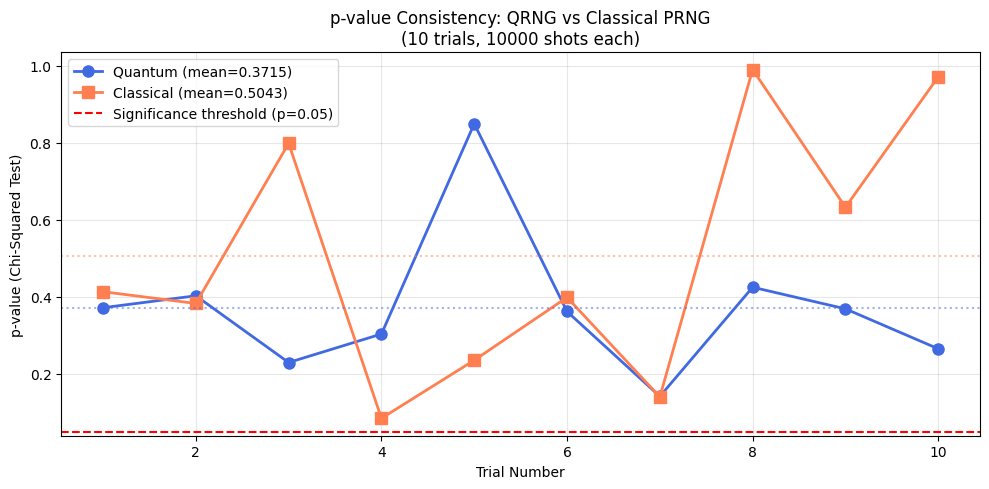


Quantum  -- Mean: 0.3715 | Std: 0.1792
Classical -- Mean: 0.5043 | Std: 0.3117


In [22]:
# ── Plot Multiple Trials ──────────────────────────────────
def plot_multiple_trials(n_bits=4, shots=10000, trials=10):
    """
    Plot p-values across multiple trials for both generators.
    Shows consistency of each generator.
    """
    q_pvalues = []
    c_pvalues = []

    for i in range(trials):
        q_counts = quantum_rng(n_bits=n_bits, shots=shots)
        c_counts = classical_rng(n_bits=n_bits, shots=shots)

        all_states = [format(j, f'0{n_bits}b') for j in range(2**n_bits)]
        q_obs = [q_counts.get(s, 0) for s in all_states]
        c_obs = [c_counts.get(s, 0) for s in all_states]

        _, q_p = chisquare(q_obs)
        _, c_p = chisquare(c_obs)

        q_pvalues.append(round(q_p, 4))
        c_pvalues.append(round(c_p, 4))

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, trials+1), q_pvalues, 'o-',
             color='royalblue', label=f'Quantum (mean={np.mean(q_pvalues):.4f})',
             linewidth=2, markersize=8)
    plt.plot(range(1, trials+1), c_pvalues, 's-',
             color='coral', label=f'Classical (mean={np.mean(c_pvalues):.4f})',
             linewidth=2, markersize=8)
    plt.axhline(y=0.05, color='red', linestyle='--',
                label='Significance threshold (p=0.05)')
    plt.axhline(y=np.mean(q_pvalues), color='royalblue',
                linestyle=':', alpha=0.5)
    plt.axhline(y=np.mean(c_pvalues), color='coral',
                linestyle=':', alpha=0.5)
    plt.xlabel('Trial Number')
    plt.ylabel('p-value (Chi-Squared Test)')
    plt.title(f'p-value Consistency: QRNG vs Classical PRNG\n({trials} trials, {shots} shots each)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('qrng_multiple_trials.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nQuantum  -- Mean: {np.mean(q_pvalues):.4f} | Std: {np.std(q_pvalues):.4f}")
    print(f"Classical -- Mean: {np.mean(c_pvalues):.4f} | Std: {np.std(c_pvalues):.4f}")

plot_multiple_trials()

# Results Logging 3

In [23]:
# ── Experiment Log 003: Multiple Trials at 10,000 shots ──
experiment_log_003 = {
    "experiment_id": "qi26_26_QRNG_003",
    "benchmark_type": "QRNG",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "circuit_params": {
        "qubits": 4,
        "depth": 1,
        "shots": 10000,
        "gates": {"H": 4}
    },
    "metrics": {
        "trials": 10,
        "quantum": {
            "mean_pvalue": 0.3715,
            "std_pvalue": 0.1792,
            "fail_rate": "0/10"
        },
        "classical": {
            "mean_pvalue": 0.5043,
            "std_pvalue": 0.3117,
            "fail_rate": "0/10"
        }
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Quantum shows more consistent uniformity across 10 trials (std=0.1792 vs 0.3117). Both pass chi-squared test."
}

with open('qrng_experiment_003.json', 'w') as f:
    json.dump(experiment_log_003, f, indent=2)

print("Experiment 003 logged:")
print(json.dumps(experiment_log_003, indent=2))

Experiment 003 logged:
{
  "experiment_id": "qi26_26_QRNG_003",
  "benchmark_type": "QRNG",
  "timestamp": "2026-07-06T13:36:01.034030+00:00",
  "simulator": "LocalSimulator",
  "circuit_params": {
    "qubits": 4,
    "depth": 1,
    "shots": 10000,
    "gates": {
      "H": 4
    }
  },
  "metrics": {
    "trials": 10,
    "quantum": {
      "mean_pvalue": 0.3715,
      "std_pvalue": 0.1792,
      "fail_rate": "0/10"
    },
    "classical": {
      "mean_pvalue": 0.5043,
      "std_pvalue": 0.3117,
      "fail_rate": "0/10"
    }
  },
  "environment": {
    "braket_sdk_version": "1.121.0",
    "python_version": "3.12",
    "region": "us-east-1"
  },
  "notes": "Quantum shows more consistent uniformity across 10 trials (std=0.1792 vs 0.3117). Both pass chi-squared test."
}


### Multi-Qubit Analysis: Does Qubit Count Affect Randomness Quality?
Testing QRNG with 2, 4, 6, and 8 qubits to see how circuit size affects uniformity.

In [25]:
# ── Multi-Qubit Analysis ──────────────────────────────────
def qubit_sweep(qubit_counts=[2, 4, 6, 8], shots=10000):
    """
    Test QRNG with different qubit counts.
    More qubits = more possible states = harder to achieve uniform distribution.
    """
    results = []

    for n_bits in qubit_counts:
        q_counts = quantum_rng(n_bits=n_bits, shots=shots)
        c_counts = classical_rng(n_bits=n_bits, shots=shots)

        all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
        q_obs = [q_counts.get(s, 0) for s in all_states]
        c_obs = [c_counts.get(s, 0) for s in all_states]

        _, q_p = chisquare(q_obs)
        _, c_p = chisquare(c_obs)

        results.append({
            'qubits': n_bits,
            'possible_states': 2**n_bits,
            'shots': shots,
            'quantum_p': round(q_p, 4),
            'classical_p': round(c_p, 4),
            'quantum_result': 'PASS' if q_p > 0.05 else 'FAIL',
            'classical_result': 'PASS' if c_p > 0.05 else 'FAIL'
        })

        print(f"Qubits: {n_bits} | States: {2**n_bits:4d} | Q p={q_p:.4f} ({('PASS' if q_p > 0.05 else 'FAIL')}) | C p={c_p:.4f} ({('PASS' if c_p > 0.05 else 'FAIL')})")

    return results

qubit_results = qubit_sweep()

Qubits: 2 | States:    4 | Q p=0.0746 (PASS) | C p=0.9976 (PASS)
Qubits: 4 | States:   16 | Q p=0.0495 (FAIL) | C p=0.2918 (PASS)
Qubits: 6 | States:   64 | Q p=0.9599 (PASS) | C p=0.1105 (PASS)
Qubits: 8 | States:  256 | Q p=0.2161 (PASS) | C p=0.0748 (PASS)


### Multi-Qubit Visualization

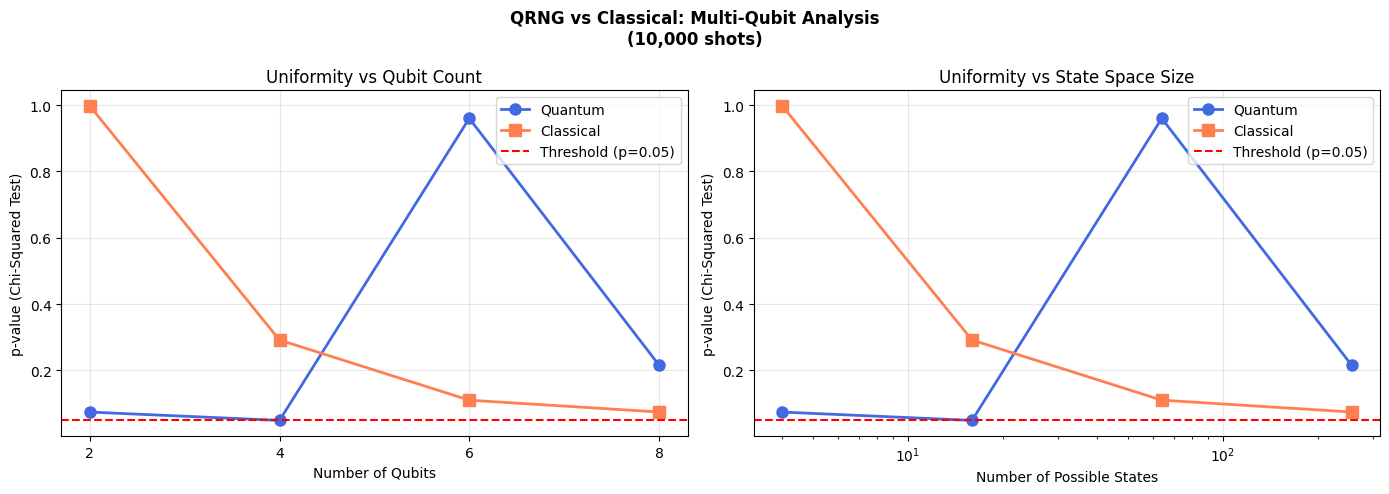

Qubit sweep plot saved!


In [26]:
# ── Plot Qubit Sweep ──────────────────────────────────────
def plot_qubit_sweep(qubit_results):

    qubits = [r['qubits'] for r in qubit_results]
    q_pvalues = [r['quantum_p'] for r in qubit_results]
    c_pvalues = [r['classical_p'] for r in qubit_results]
    states = [r['possible_states'] for r in qubit_results]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: p-values vs qubit count
    axes[0].plot(qubits, q_pvalues, 'o-', color='royalblue',
                 label='Quantum', linewidth=2, markersize=8)
    axes[0].plot(qubits, c_pvalues, 's-', color='coral',
                 label='Classical', linewidth=2, markersize=8)
    axes[0].axhline(y=0.05, color='red', linestyle='--',
                    label='Threshold (p=0.05)')
    axes[0].set_xlabel('Number of Qubits')
    axes[0].set_ylabel('p-value (Chi-Squared Test)')
    axes[0].set_title('Uniformity vs Qubit Count')
    axes[0].set_xticks(qubits)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: p-values vs number of possible states
    axes[1].plot(states, q_pvalues, 'o-', color='royalblue',
                 label='Quantum', linewidth=2, markersize=8)
    axes[1].plot(states, c_pvalues, 's-', color='coral',
                 label='Classical', linewidth=2, markersize=8)
    axes[1].axhline(y=0.05, color='red', linestyle='--',
                    label='Threshold (p=0.05)')
    axes[1].set_xlabel('Number of Possible States')
    axes[1].set_ylabel('p-value (Chi-Squared Test)')
    axes[1].set_title('Uniformity vs State Space Size')
    axes[1].set_xscale('log')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('QRNG vs Classical: Multi-Qubit Analysis\n(10,000 shots)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('qrng_qubit_sweep.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Qubit sweep plot saved!")

plot_qubit_sweep(qubit_results)

# Results Logging 4

In [27]:
# ── Experiment Log 004: Multi-Qubit Analysis ─────────────
experiment_log_004 = {
    "experiment_id": "qi26_26_QRNG_004",
    "benchmark_type": "QRNG",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "circuit_params": {
        "qubit_counts": [2, 4, 6, 8],
        "shots": 10000,
        "depth": 1
    },
    "metrics": {
        "qubit_sweep": [
            {"qubits": 2, "states": 4,   "quantum_p": 0.0746, "classical_p": 0.9976, "quantum_result": "PASS", "classical_result": "PASS"},
            {"qubits": 4, "states": 16,  "quantum_p": 0.0495, "classical_p": 0.2918, "quantum_result": "FAIL", "classical_result": "PASS"},
            {"qubits": 6, "states": 64,  "quantum_p": 0.9599, "classical_p": 0.1105, "quantum_result": "PASS", "classical_result": "PASS"},
            {"qubits": 8, "states": 256, "quantum_p": 0.2161, "classical_p": 0.0748, "quantum_result": "PASS", "classical_result": "PASS"}
        ]
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Classical p-value drops consistently as qubit count increases. At 8 qubits classical approaches failure threshold. Quantum shows better uniformity at larger state spaces but needs more shots for reliable statistics."
}

with open('qrng_experiment_004.json', 'w') as f:
    json.dump(experiment_log_004, f, indent=2)

print("Experiment 004 logged!")

Experiment 004 logged!


In [29]:
from google.colab import files
files.download('qrng_experiment_001.json')
files.download('qrng_experiment_002.json')
files.download('qrng_experiment_003.json')
files.download('qrng_experiment_004.json')
files.download('qrng_comparison.png')
files.download('qrng_shot_sweep.png')
files.download('qrng_multiple_trials.png')
files.download('qrng_qubit_sweep.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>